# Sesión 6: Forecasting con LSTM + Características TDA

## Objetivo
Reemplazar el modelo RandomForest de Sesión 5 con una LSTM multivariada que ingiere características topológicas (TDA) como canales temporales. Comparar MAE, RMSE y R² en el conjunto de prueba.

**Fuente de datos:** WPUSI01102B.csv  
**Periodo:** Jun 2008 – Abr 2026 (215 puntos mensuales)

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from gtda.time_series import SingleTakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceEntropy, Amplitude, BettiCurve
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)
print(f"TensorFlow {tf.__version__}")

TensorFlow 2.21.0


In [79]:
# ── Data ──────────────────────────────────────────────────
df = pd.read_csv('WPUSI01102B.csv', parse_dates=['observation_date'])
prices = df['WPUSI01102B'].values.astype(float)
dates  = df['observation_date'].values
print(f"Total samples: {len(prices)}  ({dates[0]} → {dates[-1]})")

# ── TDA rolling-window constants ──────────────────────────
W   = 36   # rolling window length (months)
D   = 6    # Takens embedding dimension
TAU = 3    # Takens time delay
# Takens embedding produces W - (D-1)*TAU points: 36 - (6-1)*3 = 21 delay-vectors per window
EMBED_PTS = W - (D - 1) * TAU
print(f"Embedding points per window: {EMBED_PTS}")   # expect 21

# ── LSTM constants ────────────────────────────────────────
L          = 12    # LSTM lookback (months of feature vectors)
N_BINS     = 10    # BettiCurve bins per homology dim (10×2 = 20)
# Features: price(1) + entropy(2) + amplitude(2) + max_H1(1) + betti(20) + takens_raw(21×6=126)
N_FEATURES = 152

Total samples: 215  (2008-06-01T00:00:00.000000 → 2026-04-01T00:00:00.000000)
Embedding points per window: 21


## 1. Extracción de Características TDA (ventana deslizante W=36)

Para cada mes `t` desde el índice 35 hasta 214, calculamos:
- Embedding de Takens sobre `prices[t-35:t+1]` (36 meses, d=6, τ=3)
- Persistencia de Vietoris-Rips → diagrama H₀ y H₁
- Características: PersistenceEntropy (×2), Amplitude (×2), max H₁ persistence (×1), BettiCurve 10-bins (×20)
- Embedding de Takens aplanado (21×6 = ×126)
- Total: **152 características** por vector

In [80]:
# ── Instantiate TDA transformers ──────────────────────────
STE = SingleTakensEmbedding(parameters_type="fixed", dimension=D, time_delay=TAU)
VR  = VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)
PE  = PersistenceEntropy(nan_fill_value=0.0)
AMP = Amplitude()
BC  = BettiCurve(n_bins=N_BINS)

# ── Rolling extraction ────────────────────────────────────
feature_list = []
n_total = len(prices)

for t in range(W - 1, n_total):
    window = prices[t - W + 1 : t + 1]            # shape (36,)

    embedding   = STE.fit_transform(window)         # shape (21, 6)
    emb_3d      = embedding[np.newaxis, :, :]       # shape (1, 21, 6)

    diagrams    = VR.fit_transform(emb_3d)          # shape (1, n_pts, 3)

    pe  = PE.fit_transform(diagrams)[0]             # shape (2,)  [H0, H1]
    amp = AMP.fit_transform(diagrams)[0]            # shape (2,)  [H0, H1]

    diag        = diagrams[0]                       # shape (n_pts, 3)
    h1_mask     = diag[:, 2] == 1
    max_h1      = float(np.max(diag[h1_mask, 1] - diag[h1_mask, 0])) \
                  if np.any(h1_mask) else 0.0       # scalar

    bc_flat     = BC.fit_transform(diagrams)[0].flatten()  # shape (20,)

    # price(1) + entropy(2) + amplitude(2) + max_h1(1) + betti(20) + raw_embedding(126) = 152
    feat = np.concatenate([[prices[t]], pe, amp, [max_h1], bc_flat, embedding.flatten()])
    feature_list.append(feat)

F = np.array(feature_list)   # shape (180, 152)
print(f"Feature matrix F: {F.shape}")   # expect (180, 152)
print(f"Any NaN: {np.isnan(F).any()}")  # expect False

Feature matrix F: (180, 152)
Any NaN: False


In [81]:
np.save('F_tda_features.npy', F)
print("Saved F_tda_features.npy")
# To reload in a fresh kernel run: F = np.load('F_tda_features.npy')

Saved F_tda_features.npy


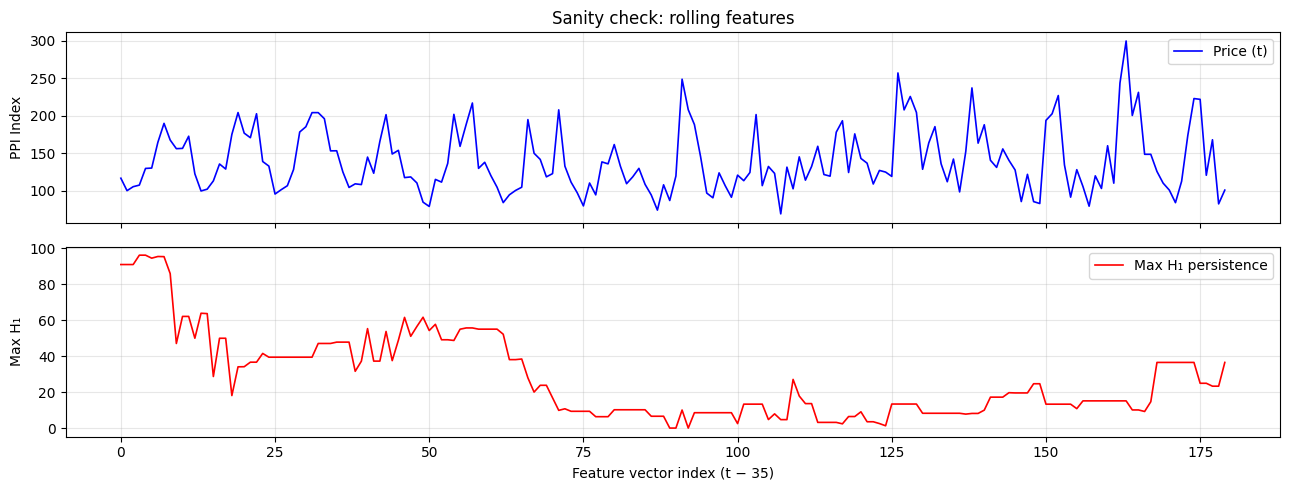

In [82]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 5), sharex=True)

ax1.plot(F[:, 0], 'b-', linewidth=1.2, label='Price (t)')
ax1.set_ylabel('PPI Index')
ax1.set_title('Sanity check: rolling features')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(F[:, 5], 'r-', linewidth=1.2, label='Max H₁ persistence')
ax2.set_xlabel('Feature vector index (t − 35)')
ax2.set_ylabel('Max H₁')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Construcción de Secuencias LSTM y División Cronológica

Ventana deslizante de longitud L=12 sobre F produce tensores (batch, 12, 26).  
División: 70% train / 15% val / 15% test (sin mezclar — tiempo estricto).

In [83]:
# X[i] = F[i:i+L],  y[i] = prices[W-1 + (i+L-1) + 1] = prices[W + i + L - 1]
# i = 0 → last window element F[L-1] covers month t=W-1+L-1=46,  target=prices[47]
# i = 167 → target = prices[47+167] = prices[214]  ✓  (last valid index)

X_list, y_list = [], []
for i in range(len(F) - L):
    X_list.append(F[i : i + L])            # (12, 26)
    target_idx = W + i + L - 1             # = 36 + i + 12 - 1 = 47 + i
    y_list.append(prices[target_idx])

X = np.array(X_list)   # (168, 12, 26)
y = np.array(y_list)   # (168,)
print(f"X: {X.shape},  y: {y.shape}")           # expect (168, 12, 26) (168,)
print(f"y range: [{y.min():.1f}, {y.max():.1f}]")

X: (168, 12, 152),  y: (168,)
y range: [69.2, 299.4]


In [84]:
n = len(X)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_train, y_train = X[:n_train],                  y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val],     y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:],            y[n_train+n_val:]

print(f"Train: {len(X_train)},  Val: {len(X_val)},  Test: {len(X_test)}")

# Normalize X — fit on train only
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(
    X_train.reshape(-1, N_FEATURES)).reshape(X_train.shape)
X_val_s   = scaler_X.transform(
    X_val.reshape(-1, N_FEATURES)).reshape(X_val.shape)
X_test_s  = scaler_X.transform(
    X_test.reshape(-1, N_FEATURES)).reshape(X_test.shape)

# Normalize y — fit on train only
scaler_y = StandardScaler()
y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_s   = scaler_y.transform(y_val.reshape(-1, 1)).flatten()
# y_test kept in original scale; inverse-transform predictions instead
print("Scalers fit on train only ✓")

Train: 117,  Val: 25,  Test: 26
Scalers fit on train only ✓


## 3. Baseline: RandomForest

Mismo input (12×26 aplanado a 312 features), misma división, mismos escaladores.  
Sirve como comparación directa con el modelo LSTM.

In [85]:
# Flatten for RF
X_train_rf = X_train_s.reshape(len(X_train_s), -1)   # (117, 312)
X_val_rf   = X_val_s.reshape(len(X_val_s),   -1)
X_test_rf  = X_test_s.reshape(len(X_test_s), -1)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_rf, y_train_s)

y_pred_rf_s  = rf.predict(X_test_rf)                           # scaled
y_pred_rf    = scaler_y.inverse_transform(
    y_pred_rf_s.reshape(-1, 1)).flatten()                      # original scale

rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2   = r2_score(y_test, y_pred_rf)

print("── RandomForest baseline (test set) ─────────────────")
print(f"  MAE  : {rf_mae:.4f}")
print(f"  RMSE : {rf_rmse:.4f}")
print(f"  R²   : {rf_r2:.4f}")

── RandomForest baseline (test set) ─────────────────
  MAE  : 38.7105
  RMSE : 48.9645
  R²   : 0.2647


## 4. Modelo LSTM + TDA

Arquitectura: LSTM(64) → LSTM(32) → Dense(16) → Dense(1)  
Input: (batch, 12, 152) — 12 pasos temporales, 152 características por paso:
- 26 resúmenes TDA (entropía, amplitud, max H₁, curvas de Betti)
- 126 puntos crudos del embedding de Takens (21 puntos × 6 dimensiones)

Loss: **MAE** (más robusto que MSE, evita colapso hacia la media).  
Early stopping con patience=20 sobre val_loss.

In [86]:
model = Sequential([
    LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1,
         input_shape=(L, N_FEATURES)),
    LSTM(32, dropout=0.2, recurrent_dropout=0.1),
    Dense(16, activation='relu'),
    Dense(1)
], name="LSTM_TDA")

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='mae', metrics=['mse'])
model.summary()

Model: "LSTM_TDA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 12, 64)         │        55,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,513 (267.63 KB)

 Trainable params: 68,513 (267.63 KB)

 Non-trainable params: 0 (0.00 B)

In [87]:
early_stop = EarlyStopping(monitor='val_loss', patience=20,
                           restore_best_weights=True, verbose=1)

history = model.fit(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)
print(f"Stopped at epoch {len(history.history['loss'])}")

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.8082 - mse: 0.9802 - val_loss: 0.8055 - val_mse: 1.0580
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7034 - mse: 0.8208 - val_loss: 0.7758 - val_mse: 0.9462
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6250 - mse: 0.6856 - val_loss: 0.7418 - val_mse: 0.8658
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5567 - mse: 0.5690 - val_loss: 0.7170 - val_mse: 0.7794
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5006 - mse: 0.5223 - val_loss: 0.7255 - val_mse: 0.7845
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4883 - mse: 0.4906 - val_loss: 0.7040 - val_mse: 0.7170
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4808 - mse: 0.4507 - val_loss: 0.6911 - val_mse: 0.6809
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4466 - mse: 0.3971 - val_loss: 0.6869 - val_mse: 0.6692
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4598 - mse: 0.4281 

## 5. Evaluación y Comparación

Métricas en el conjunto de prueba (escala original PPI).  
Comparación: RandomForest baseline vs LSTM + TDA.

In [88]:
y_pred_lstm_s = model.predict(X_test_s).flatten()
y_pred_lstm   = scaler_y.inverse_transform(
    y_pred_lstm_s.reshape(-1, 1)).flatten()

lstm_mae  = mean_absolute_error(y_test, y_pred_lstm)
lstm_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
lstm_r2   = r2_score(y_test, y_pred_lstm)

print("── LSTM + TDA (test set) ─────────────────────────────")
print(f"  MAE  : {lstm_mae:.4f}")
print(f"  RMSE : {lstm_rmse:.4f}")
print(f"  R²   : {lstm_r2:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step
── LSTM + TDA (test set) ─────────────────────────────
  MAE  : 29.4890
  RMSE : 37.5017
  R²   : 0.5687


In [89]:
results = pd.DataFrame({
    'Modelo':  ['RandomForest (baseline)', 'LSTM + TDA'],
    'MAE':     [rf_mae,   lstm_mae],
    'RMSE':    [rf_rmse,  lstm_rmse],
    'R²':      [rf_r2,    lstm_r2],
})
results = results.set_index('Modelo')
print("\n" + "="*55)
print("   COMPARACIÓN DE MODELOS — Conjunto de Prueba")
print("="*55)
print(results.round(4).to_string())
print("="*55)


   COMPARACIÓN DE MODELOS — Conjunto de Prueba
                             MAE     RMSE      R²
Modelo                                           
RandomForest (baseline)  38.7105  48.9645  0.2647
LSTM + TDA               29.4890  37.5017  0.5687


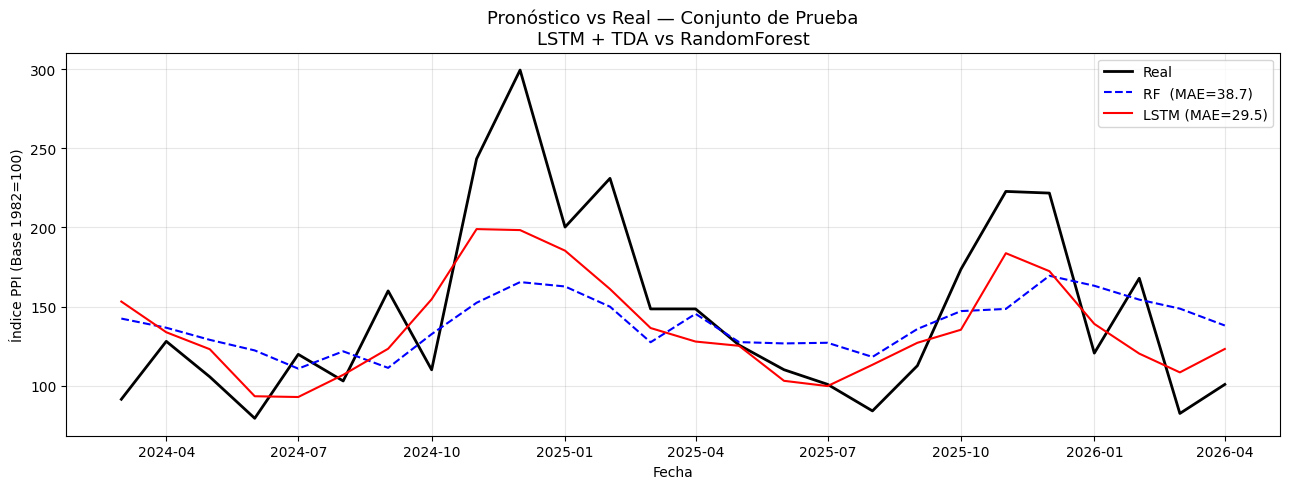

In [90]:
# Recover dates for test period
test_start_t = W - 1 + n_train + n_val + L - 1 + 1   # t+1 = target month
test_dates   = dates[test_start_t : test_start_t + len(y_test)]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_dates, y_test,      'k-',  linewidth=2,   label='Real')
ax.plot(test_dates, y_pred_rf,   'b--', linewidth=1.5, label=f'RF  (MAE={rf_mae:.1f})')
ax.plot(test_dates, y_pred_lstm, 'r-',  linewidth=1.5, label=f'LSTM (MAE={lstm_mae:.1f})')
ax.set_xlabel('Fecha')
ax.set_ylabel('Índice PPI (Base 1982=100)')
ax.set_title('Pronóstico vs Real — Conjunto de Prueba\nLSTM + TDA vs RandomForest', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Preguntas de Análisis

1. **¿El LSTM mejoró sobre el RandomForest?** Compara MAE, RMSE y R². 
   ¿En qué métrica es más notable la diferencia?

2. **Curvas de aprendizaje:** ¿Hay señales de sobreajuste (val_loss sube mientras train_loss baja)?
   ¿Cuántas épocas usó el early stopping?

3. **Tamaño de muestra:** Con solo 117 muestras de entrenamiento, 
   ¿qué limitaciones estructurales tiene el LSTM? ¿Cómo podría mitigarse?

4. **Características TDA:** ¿Por qué incluir la evolución temporal de la entropía de persistencia 
   (en lugar de calcularla una sola vez) podría ayudar al LSTM a detectar cambios de régimen?

5. **Ventana W=36:** ¿Qué pasa si cambias W a 24 o 48 meses? 
   ¿Cómo afecta el número de puntos en el embedding y la calidad de la homología?